# Summary - Process Trees EDA

## Part I 

### Build graph $G$ and find the connected components 
1. From the ```process_uber_summary``` table, build an ```igraph``` directed graph $G$ where each edge is of the form: ```parent PID --> child PID```
2. Enrich $G$ with metadata for each PID (process name, timestamp, username, sigma labels, etc.)
3. Get all (weak) connected components from $G$ -- those are the ```process trees``` (with one exception where a loop is present, which we drop), and save those in the **Trees** object

* 99.98% of components are of size 2 (1,111,052  out of 1,111,278) ...
* 210 process trees contain between 3 and 10k nodes
* 15 have more then 10k nodes

### Build DataFrame with process subtrees and statistics
For process tree of size [3,10k], we build every subtree of size 3 or more where root has a process name and for each, we save:
1. The tree and root node indices in the **Trees** object
2. Number of nodes, leaves, tree depth, number of nodes at each level, list of process names at each level
3. Number of splits (forks of size 2 or more) and ratio of splits to nodes (this can be used to filter broom-like trees, for example)
4. Number of processes from a *baduser*
5. Save the above in dataframe **process_df**


## Part II

Two simple validation experiments using the subtrees in **process_df**: clustering and nearest neighbours.

## Part III

Using the Acme4 process tree data saved in the **Trees** and **process_df** objects, generate some illustrative plots using our **Basic Matching Algorithm:** 
* Algorithm 1 from: "The Needle is a Thread: Finding Planted Paths in Noisy Process Trees", M. Le, P. Pralat, A. Smith and F. Theberge, https://arxiv.org/abs/2602.04694.

This algorithm finds matching paths in trees using node labels.

# Preliminary steps

The first few cells are taken from BH's ```process-name-curation``` notebook


In [1]:
%load_ext autoreload
%load_ext dotenv
#%load_ext quak 
%load_ext sql

Tip: You may define configurations in /work/home/fcthebe/Acme4/Forked/Wintap-Analytics/2025-acme4-explore/pyproject.toml or /work/home/fcthebe/.jupysql/config.

Did not find user configurations in /work/home/fcthebe/Acme4/Forked/Wintap-Analytics/2025-acme4-explore/pyproject.toml.

In [2]:
%autoreload 1
%aimport acme4_explore

In [3]:
import acme4_explore
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import seaborn as sns
from collections import Counter
import igraph as ig
import pickle
import gzip
from tqdm.auto import tqdm 
import logging as lg

## our matching algorithm
import igraph_io as igio
import gw_matcher as gwm ## older code - for testing
import fast_match as fm  ## fast version

## several utility functions
import process_trees as pt


In [4]:
# Registers the current `tqdm` class with pandas.core.
tqdm.pandas()


In [5]:
lg.basicConfig(**acme4_explore.logging_config())
LOG = lg.getLogger("notebook")


In [6]:
db = acme4_explore.connect_db()
%sql db --alias duckdb
%config SqlMagic.displaycon=False
%config SqlMagic.autopandas=True


# Part I --  Build process trees from the ```process_uber_summary``` table

* we use a subset of the columns to build the process trees
* followed by some EDA


In [7]:
%%sql process_summary <<
select * from process_uber_summary


In [8]:
%%time
Trees, df_trees = pt.build_process_trees(process_summary, min_tree_size=3, max_tree_size=10000) ## those are for the subtrees, whole trees can be larger
df_trees['split_ratio_nodes'] = df_trees['splits'] / df_trees['nodes']


CPU times: user 46.7 s, sys: 1.31 s, total: 48 s
Wall time: 48 s


### Examples

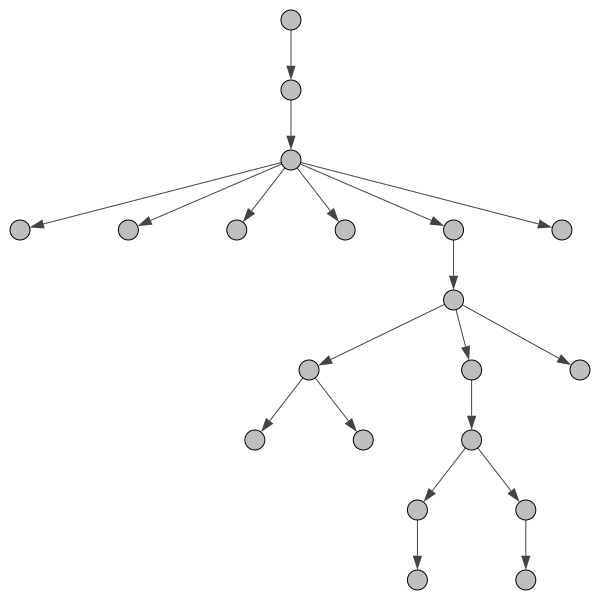

In [9]:
## ex: showing a size 20 component
idx = np.where(np.array(Trees.sizes())==20)[0][0]
sg = Trees.subgraph(idx)
ly = sg.layout_reingold_tilford()
#ig.plot(sg, 'smalltree_1.png', layout=ly, vertex_color='grey', vertex_label_size=0)
ig.plot(sg, layout=ly, vertex_color='grey', vertex_label_size=0)


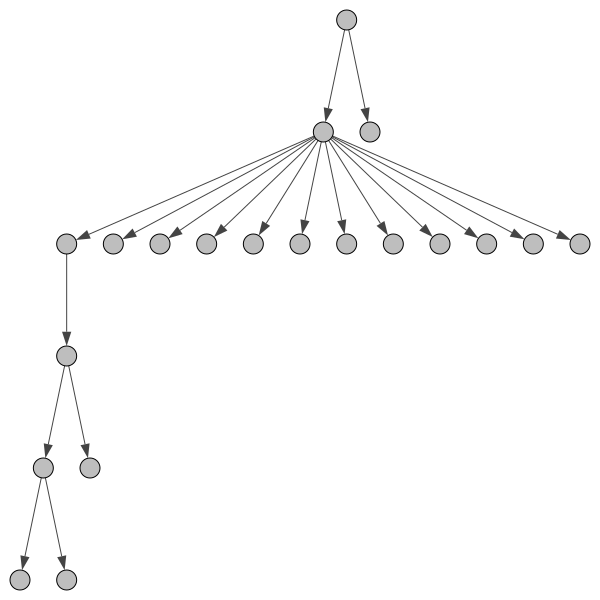

In [10]:
## ex: showing another size 20 component
idx = np.where(np.array(Trees.sizes())==20)[0][1]
sg = Trees.subgraph(idx)
ly = sg.layout_reingold_tilford()
#ig.plot(sg, 'smalltree_2.png', layout=ly, vertex_color='grey', vertex_label_size=0)
ig.plot(sg, layout=ly, vertex_color='grey', vertex_label_size=0)


### Process tree sizes

We dropped trees of size 2 already


In [11]:
## largest tree
print('largest subtree:',np.max([len(x) for x in Trees]))

## size of the Trees
print('number of PIDs:',len(Trees.membership),'number of components:',len(set(Trees.membership)))
print('Most frequent tree sizes:')
Counter([len(x) for x in Trees]).most_common(12)


largest subtree: 257744
number of PIDs: 627384 number of components: 230
Most frequent tree sizes:


[(3, 94),
 (4, 23),
 (5, 12),
 (12, 11),
 (6, 8),
 (7, 4),
 (13, 4),
 (9, 3),
 (119, 2),
 (10, 2),
 (20, 2),
 (24610, 1)]

In [12]:
## dataframe with all subtrees
print('number of subtrees:',df_trees.shape[0])
df_trees.head()


number of subtrees: 2710


,tree,root,process,nodes,layers,leaves,bad3,bad9,bad25,splits,distribution,badusers,split_ratio_nodes
0,7,34,ssm-document-worker.exe,7,2,6,0,0,0,1,"[1, 6]",0,0.142857
1,7,40,ngentask.exe,4,2,3,0,0,0,1,"[1, 3]",0,0.250000
2,7,42,compattelrunner.exe,5,2,4,0,0,0,1,"[1, 4]",0,0.200000
3,7,60,ssm-document-worker.exe,12,2,11,0,0,0,1,"[1, 11]",0,0.083333
4,7,146,compattelrunner.exe,5,2,4,0,0,0,1,"[1, 4]",0,0.200000


### common process and layer size distribution

The most common (sub)-process trees (with a root process) are very shallow. 


In [13]:
Counter([str(i)+' '+str(j) for i,j in zip (df_trees.process, df_trees.distribution)]).most_common(20)


[('git.exe [1 2]', 353),
 ('ngentask.exe [1 3]', 290),
 ('bash.exe [1 1 1]', 170),
 ('bash.exe [1 2 2 1]', 134),
 ('taskhostw.exe [1 2 6]', 133),
 ('bash.exe [1 2 1]', 129),
 ('cmd.exe [1 2]', 111),
 ('compattelrunner.exe [1 4]', 80),
 ('compattelrunner.exe [1 2]', 69),
 ('ssm-document-worker.exe [ 1 11]', 47),
 ('winlogon.exe [1 3]', 46),
 ('cmd.exe [1 2 1]', 43),
 ('smss.exe [1 2 3]', 41),
 ('bash.exe [1 1 1 1]', 29),
 ('aws.exe [1 1 1]', 24),
 ('cmd.exe [1 1 1 1]', 17),
 ('cmd.exe [1 1 1]', 17),
 ('downloadfroms3.exe [1 1 1]', 16),
 ('microsoftedgeupdate.exe [1 2 1 4 3]', 14),
 ('setup.exe [1 4 3]', 14)]

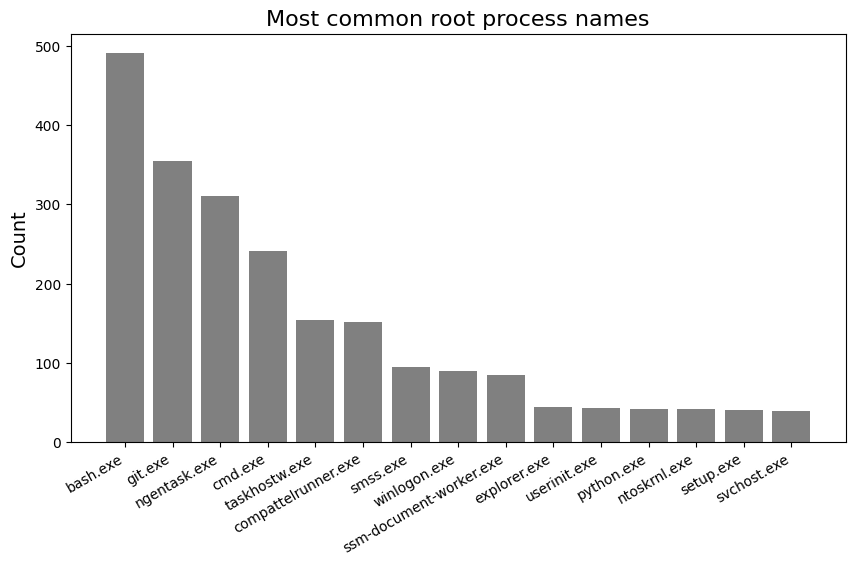

In [14]:
_ctr = Counter(df_trees.process)
X = np.array(list(_ctr.keys()))
Y = np.array(list(_ctr.values()))
top = np.argsort(Y)[::-1][:15]
plt.figure(figsize=(10,6))
plt.bar(X[top], Y[top], color='grey')
#plt.xlabel('process')
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=30, ha='right') 
plt.title('Most common root process names',fontsize=16)
plt.subplots_adjust(bottom=0.2)
#plt.savefig('common_root_process.png')
plt.show()

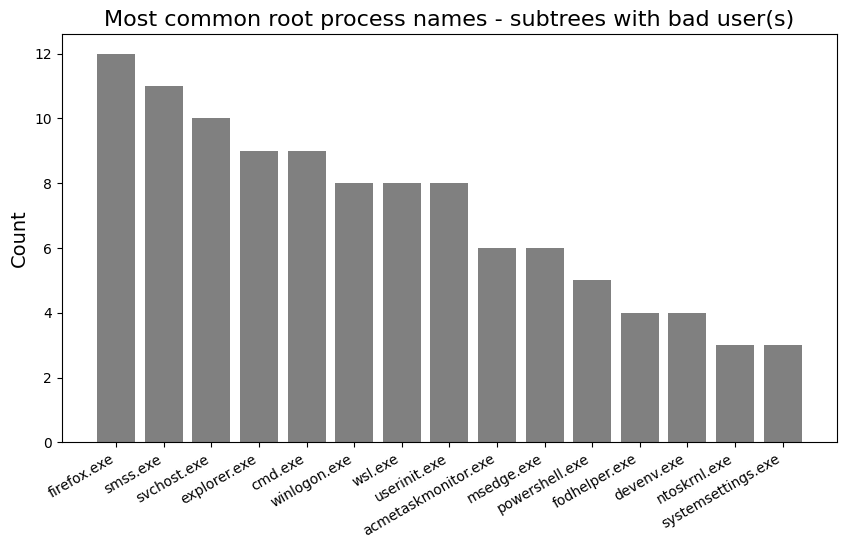

In [15]:
_ctr = Counter(df_trees[df_trees.badusers>0].process)
X = np.array(list(_ctr.keys()))
Y = np.array(list(_ctr.values()))
top = np.argsort(Y)[::-1][:15]
plt.figure(figsize=(10,6))
plt.bar(X[top], Y[top], color='grey')
#plt.xlabel('process')
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=30, ha='right') 
plt.title('Most common root process names - subtrees with bad user(s)',fontsize=16)
plt.subplots_adjust(bottom=0.2)
#plt.savefig('common_root_process_bad.png')
plt.show()

### sub-tree depth

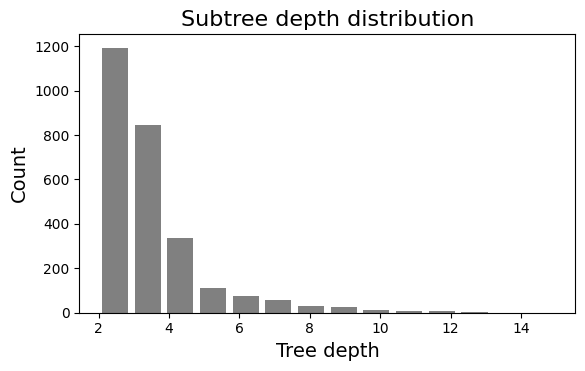

In [16]:
plt.hist(df_trees['layers'],bins=14, rwidth=.8, color='grey')
plt.xlabel('Tree depth', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Subtree depth distribution',fontsize=16)
plt.subplots_adjust(bottom=0.3)
#plt.savefig('subtree_depth.png')
plt.show()

In [17]:
## there are very few deep (sub)-trees 
df_trees[df_trees['layers']>10]


,tree,root,process,nodes,layers,leaves,bad3,bad9,bad25,splits,distribution,badusers,split_ratio_nodes
715,16,5,winlogon.exe,159,12,133,0,0,0,9,"[1, 8, 1, 9, 92, 5, 4, 3, 27, 5, 3, 1]",0,0.056604
737,16,405,smss.exe,1978,14,1858,0,40,0,46,"[1, 10, 15, 32, 207, 424, 1208, 38, 4, 3, 27, ...",40,0.023256
749,16,523,smss.exe,161,13,134,0,0,0,10,"[1, 2, 8, 1, 9, 92, 5, 4, 3, 27, 5, 3, 1]",0,0.062112
752,16,1075,userinit.exe,151,11,126,0,0,0,8,"[1, 1, 9, 92, 5, 4, 3, 27, 5, 3, 1]",0,0.052980
762,16,1563,ntoskrnl.exe,2926,15,2803,0,40,0,48,"[1, 4, 953, 16, 32, 207, 424, 1208, 38, 4, 3, ...",40,0.016405
776,18,4,smss.exe,201,11,186,119,0,0,12,"[1, 2, 6, 1, 10, 166, 3, 4, 1, 3, 4]",119,0.059701
779,18,10,smss.exe,848,12,713,360,0,0,63,"[1, 13, 18, 50, 8, 59, 606, 35, 25, 13, 14, 6]",360,0.074292
855,18,359,smss.exe,281,11,261,155,0,0,14,"[1, 2, 6, 1, 13, 241, 6, 6, 1, 2, 2]",155,0.049822
869,18,468,ntoskrnl.exe,852,13,716,360,0,0,64,"[1, 4, 13, 18, 50, 8, 59, 606, 35, 25, 13, 14, 6]",360,0.075117
1735,27,345,smss.exe,1336,11,1133,0,296,0,80,"[1, 14, 27, 51, 193, 409, 434, 149, 42, 14, 2]",296,0.059880


## Filtering

From the ```df_trees``` table, we can filter sub-trees in various ways (size, proportion of splits, etc...). We show a few examples below.


#### Example 1: small subtrees with large number of splits

We also visualize a few. Node labels are: ```short_username::process_name```


In [18]:
## extract
_df = df_trees[ (df_trees['nodes']>=10) & (df_trees['nodes']<=20) & (df_trees.split_ratio_nodes>.3) ]
_df

,tree,root,process,nodes,layers,leaves,bad3,bad9,bad25,splits,distribution,badusers,split_ratio_nodes
788,18,34,nyancat.exe,18,7,11,9,0,0,6,"[1, 2, 3, 4, 1, 3, 4]",9,0.333333
789,18,36,acmetaskmonitor.exe,16,6,10,7,0,0,5,"[1, 3, 4, 1, 3, 4]",7,0.312500
821,18,184,acmetaskmonitor.exe,15,6,9,4,0,0,5,"[1, 3, 6, 1, 2, 2]",4,0.333333
840,18,251,cmd.exe,13,5,8,5,0,0,4,"[1, 4, 1, 3, 4]",5,0.307692
871,18,573,nyancat.exe,17,7,10,6,0,0,6,"[1, 2, 3, 6, 1, 2, 2]",6,0.352941
1668,25,132,smss.exe,16,6,10,0,0,0,5,"[1, 2, 5, 1, 3, 4]",0,0.312500
2405,57,40,smss.exe,16,6,10,0,0,0,5,"[1, 2, 5, 1, 3, 4]",0,0.312500
2470,66,180,smss.exe,12,6,7,0,0,0,4,"[1, 2, 4, 1, 2, 2]",0,0.333333


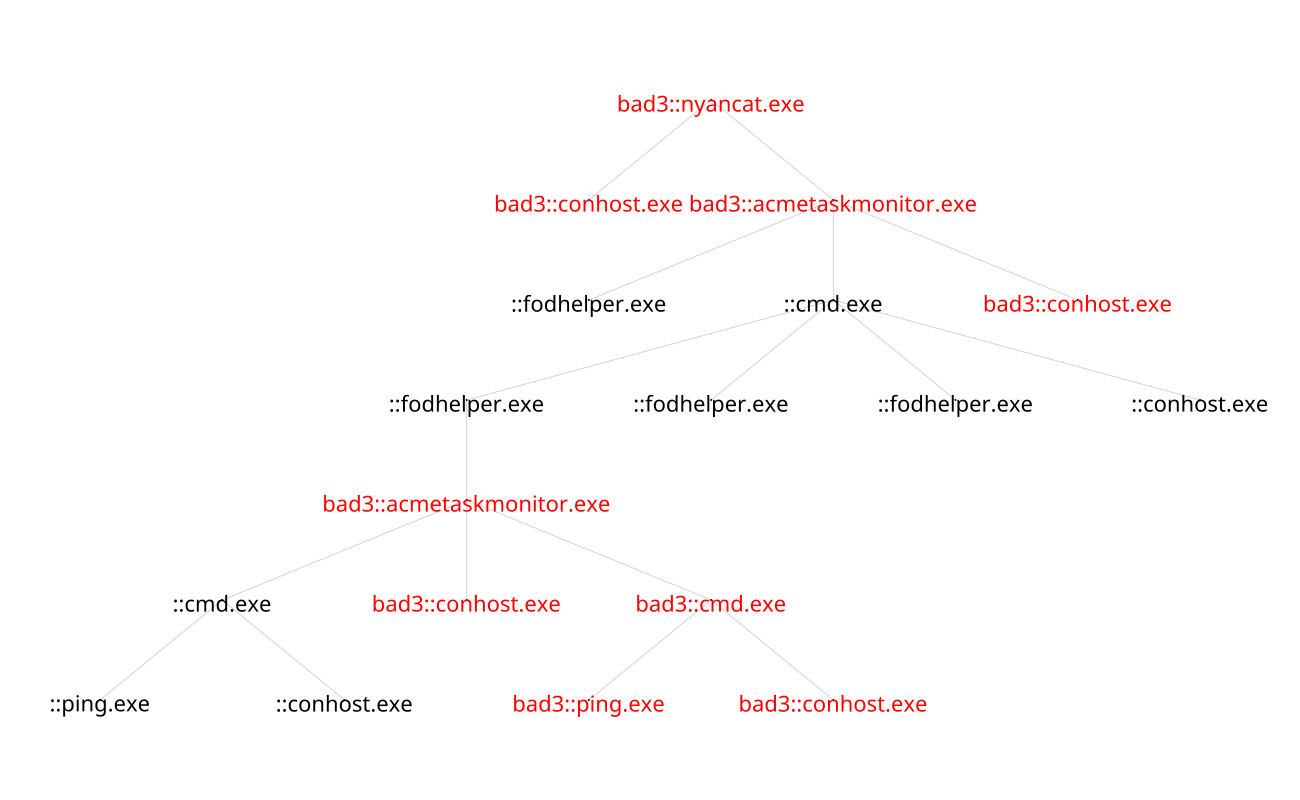

In [19]:
## visualize 
sg = pt.get_bfs_subtree(Trees, 18, 34)
ig.plot(sg, 'tree_bad_splits.png', bbox=(1300,800), margin=100, layout=sg['ly'], vertex_label_size=22, vertex_size=1, edge_color='lightgrey', edge_arrow_size=0)
#ig.plot(sg, bbox=(1200,800), margin=100, layout=sg['ly'], vertex_label_size=15, vertex_size=1, edge_color='lightgrey', edge_arrow_size=0)


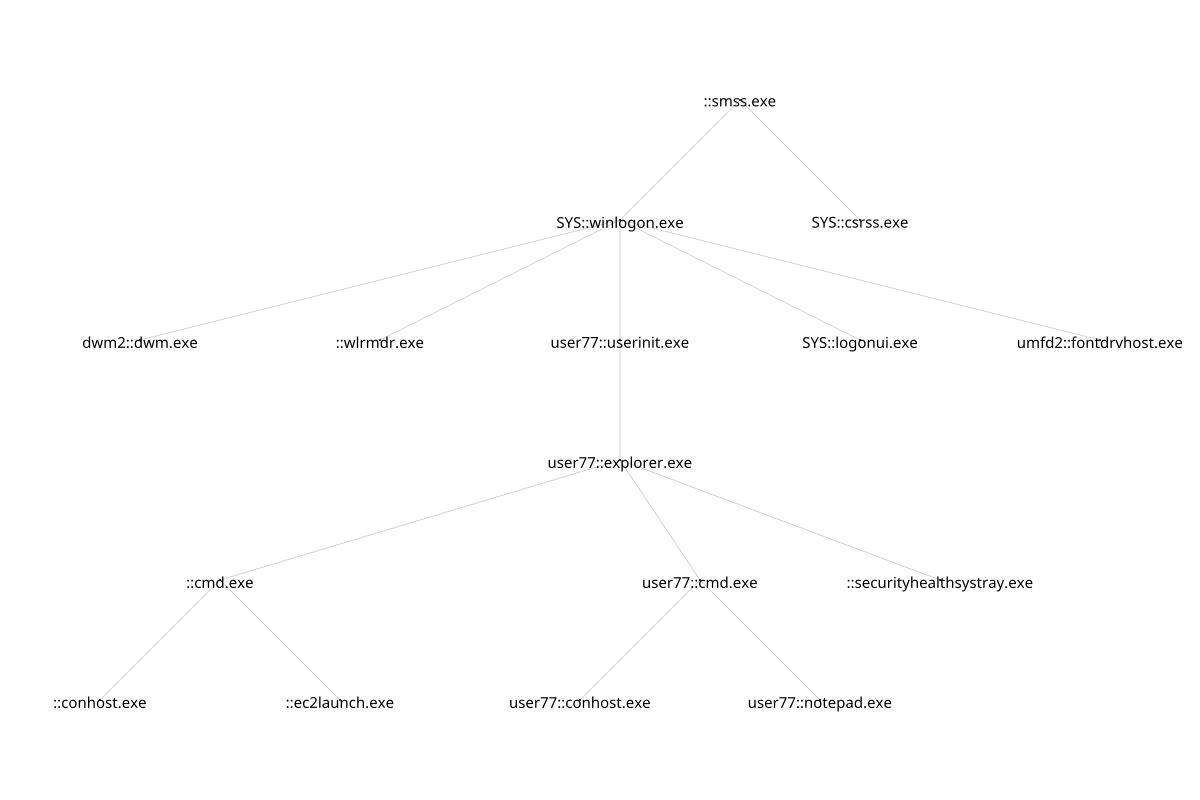

In [20]:
## visualize
sg = pt.get_bfs_subtree(Trees, 25, 132)
ig.plot(sg, bbox=(1200,800), margin=100, layout=sg['ly'], vertex_label_size=15, vertex_size=1, edge_color='lightgrey', edge_arrow_size=0)


#### Example 2 - small subtrees with few split nodes


In [21]:
## extract
_df = df_trees[ (df_trees['nodes']>=10) & (df_trees['nodes']<=20) & (df_trees.leaves<5) & (df_trees.split_ratio_nodes<.1) ]
_df


,tree,root,process,nodes,layers,leaves,bad3,bad9,bad25,splits,distribution,badusers,split_ratio_nodes
764,16,1566,setup-stub.exe,11,6,4,0,0,0,1,"[1, 1, 1, 4, 3, 1]",0,0.090909


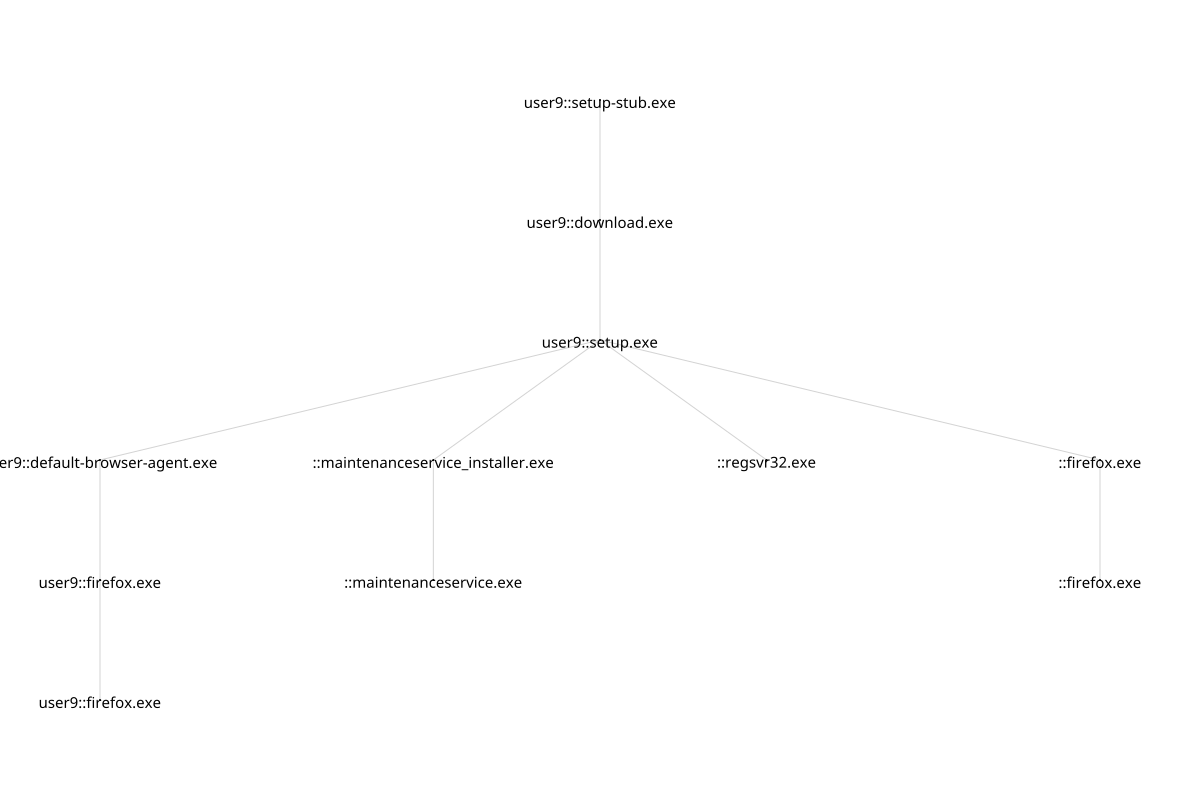

In [22]:
## visualize
sg = pt.get_bfs_subtree(Trees, 16, 1566)
ig.plot(sg, bbox=(1200,800), margin=100, layout=sg['ly'], vertex_label_size=15, vertex_size=1, edge_color='lightgrey', edge_arrow_size=0)


# Part II - Validation experiments

We run two simple experiments on the process trees listed in ```df_trees```:

* pick the 9 most common root processes and **cluster** the corresponding process trees via bag-of-features and the Szymkiewicz-Simpson (overlap) similarity score.
* using the same similarity score, look at the number of **nearest neighbours** process trees that contain some bad user ; compare this value for trees with/without bad users.


### process tree clustering via bag of features

We consider subtrees labelled with the root's process name.

We build bag of features made up of every process in the tree, by concatenating the following:

* process name
* layer (distance from root)
* counter (useful to consider multiple occurrences of the same process at the same layer)


In [23]:
## example of a subtree and its features
sg = pt.get_bfs_subtree(Trees, 25, 132)
pt.subtree_features(sg)


{'0::smss.exe::0',
 '1::csrss.exe::0',
 '1::winlogon.exe::0',
 '2::dwm.exe::0',
 '2::fontdrvhost.exe::0',
 '2::logonui.exe::0',
 '2::userinit.exe::0',
 '2::wlrmdr.exe::0',
 '3::explorer.exe::0',
 '4::cmd.exe::0',
 '4::cmd.exe::1',
 '4::securityhealthsystray.exe::0',
 '5::conhost.exe::0',
 '5::conhost.exe::1',
 '5::ec2launch.exe::0',
 '5::notepad.exe::0'}

In [24]:
## build bag of features for every subtree - this takes a few minutes
Features = []
for t,r in zip(df_trees.tree, df_trees.root):
    sg = pt.get_bfs_subtree(Trees, t, r)
    Features.append(pt.subtree_features(sg))


In [25]:
## consider the most common root process names
top_process = 9
P = list(df_trees['process'])
mc = set([x[0] for x in Counter(P).most_common(top_process)])
P_subset = [p for p in P if p in mc]
F_subset = [f for (p,f) in zip(P,Features) if p in mc]

## compute similarities
l = len(F_subset)
S = np.zeros(shape=(l,l))
for i in range(len(F_subset)-1):
    for j in np.arange(i+1,len(F_subset)):
        s = pt.szym_sim(F_subset[i],F_subset[j])
        S[i,j] = S[j,i] = s


In [26]:
## cluster - set the correct number of clusters
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=top_process, metric='precomputed', linkage='complete')
model.fit(1-S)


,n_clusters,9
,metric,'precomputed'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'complete'
,distance_threshold,None
,compute_distances,False


In [27]:
## list cluster compositions - we see good cluster separation in general
for s in range(top_process):
    print(Counter([P_subset[i] for i in np.where(model.labels_==s)[0]]))


Counter({'bash.exe': 484, 'git.exe': 355})
Counter({'smss.exe': 94})
Counter({'cmd.exe': 237})
Counter({'winlogon.exe': 89})
Counter({'taskhostw.exe': 154, 'cmd.exe': 3})
Counter({'ngentask.exe': 310})
Counter({'compattelrunner.exe': 151})
Counter({'bash.exe': 7, 'cmd.exe': 1})
Counter({'ssm-document-worker.exe': 84})


### number of badusers in nearest neighbours


In [28]:
## compute similarities
l = len(Features)
S = np.zeros(shape=(l,l))
for i in range(len(Features)-1):
    for j in np.arange(i+1,len(Features)):
        s = pt.szym_sim(Features[i],Features[j])
        S[i,j] = S[j,i] = s
        

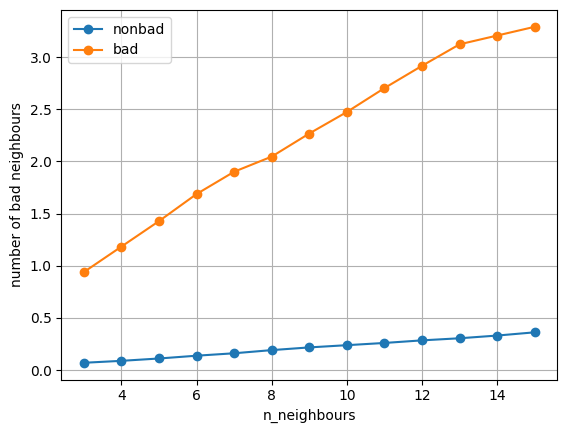

In [29]:
from sklearn.neighbors import NearestNeighbors as NN

L = []
for n in np.arange(3,16):
    model = NN(n_neighbors=n, metric='precomputed')
    model.fit(1-S)
    ## size of intersections
    _, indices = model.kneighbors()
    Bad = set(np.where(df_trees.badusers>0)[0])
    bad_nn = [len(set(v).intersection(Bad)) for v in indices]    
    ## average number of NN trees with baduser
    _temp = pd.DataFrame(np.array([list(df_trees.badusers>0) , bad_nn]).T,columns=['bad','bad_nn'])
    L.append(np.concatenate( ([n],np.array(_temp.groupby(by='bad').mean()).flatten()) ))
_df = pd.DataFrame(L, columns=['n_neighbours','nonbad','bad'])

## compare average number of 'baduser' neighbours
_df.plot('n_neighbours',['nonbad','bad'], style='o-')
plt.ylabel('number of bad neighbours')
plt.grid();


# Part III - Experiments for WAW2026 paper

* Matching Algorithm (Algorithm 1) from: "The Needle is a Thread: Finding Planted Paths in Noisy Process Trees" (M. Le, P. Pralat, A. Smith and F. Theberge), https://arxiv.org/abs/2602.04694. 
* This algorithm finds matching paths in trees using node labels, with possible gaps


### Example 1 - two trees with a matching path

* we use process names as node labels
* two trees have a common sequence: ```conhost-winlogon-userinit-explorer-cmd-conhost```
* one of those contains a bad user


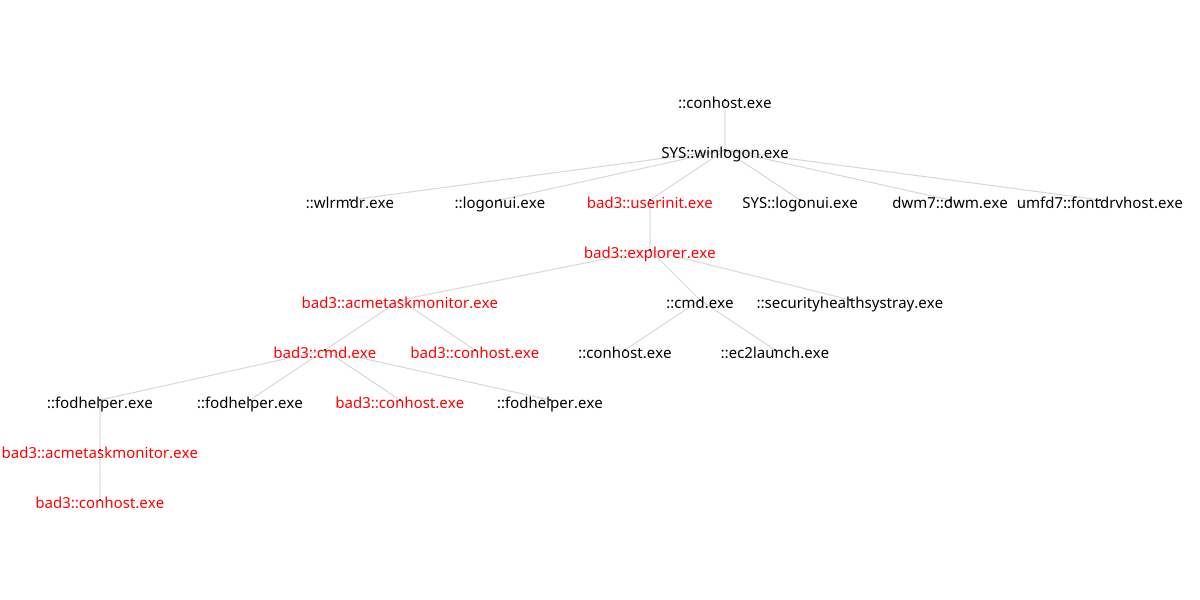

In [30]:
## visualize
sg = pt.get_bfs_subtree(Trees, 40, 7)
#ig.plot(sg, 'tree_1.png', bbox=(1200,600), margin=100, layout=sg['ly'], vertex_label_size=15, vertex_size=1, edge_color='lightgrey', edge_arrow_size=0)
ig.plot(sg, bbox=(1200,600), margin=100, layout=sg['ly'], vertex_label_size=15, vertex_size=1, edge_color='lightgrey', edge_arrow_size=0)


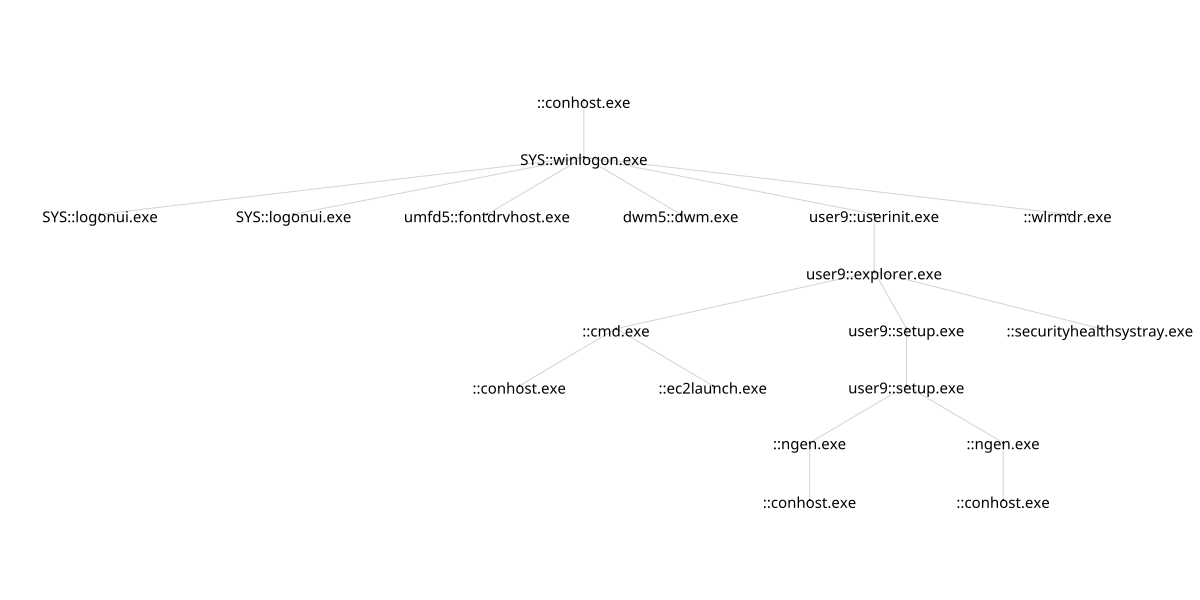

In [31]:
## visualize
sg = pt.get_bfs_subtree(Trees, 112, 5)
#ig.plot(sg, 'tree_2.png', bbox=(1200,600), margin=100, layout=sg['ly'], vertex_label_size=15, vertex_size=1, edge_color='lightgrey', edge_arrow_size=0)
ig.plot(sg, bbox=(1200,600), margin=100, layout=sg['ly'], vertex_label_size=15, vertex_size=1, edge_color='lightgrey', edge_arrow_size=0)


### Example 2 - pick a tree with baduser, find closest matches (longest matching path)

* restrict to small trees for visualisation
* select tree with 6+ layers and under 40 nodes (for easy viz)
* look for other process sub-trees with matching path(s) of at least 6 nodes
* keep hits without a baduser
                 

In [32]:
## filter subtrees with badusers
_df = df_trees[ (df_trees.layers >= 6) & (df_trees.nodes < 40) ]
_df.sort_values(by='badusers', ascending=False).head(10)


,tree,root,process,nodes,layers,leaves,bad3,bad9,bad25,splits,distribution,badusers,split_ratio_nodes
788,18,34,nyancat.exe,18,7,11,9,0,0,6,"[1, 2, 3, 4, 1, 3, 4]",9,0.333333
2211,40,7,conhost.exe,22,9,13,8,0,0,5,"[1, 1, 6, 1, 3, 4, 4, 1, 1]",8,0.227273
2213,40,18,userinit.exe,15,7,8,8,0,0,4,"[1, 1, 3, 4, 4, 1, 1]",8,0.266667
2212,40,9,winlogon.exe,21,8,13,8,0,0,5,"[1, 6, 1, 3, 4, 4, 1, 1]",8,0.238095
2209,40,3,explorer.exe,14,6,8,7,0,0,4,"[1, 3, 4, 4, 1, 1]",7,0.285714
789,18,36,acmetaskmonitor.exe,16,6,10,7,0,0,5,"[1, 3, 4, 1, 3, 4]",7,0.312500
798,18,71,smss.exe,16,6,10,7,0,0,4,"[1, 2, 6, 1, 3, 3]",7,0.250000
871,18,573,nyancat.exe,17,7,10,6,0,0,6,"[1, 2, 3, 6, 1, 2, 2]",6,0.352941
821,18,184,acmetaskmonitor.exe,15,6,9,4,0,0,5,"[1, 3, 6, 1, 2, 2]",4,0.333333
1700,27,132,systemsettings.exe,19,6,8,0,1,0,2,"[1, 1, 1, 6, 8, 2]",1,0.105263


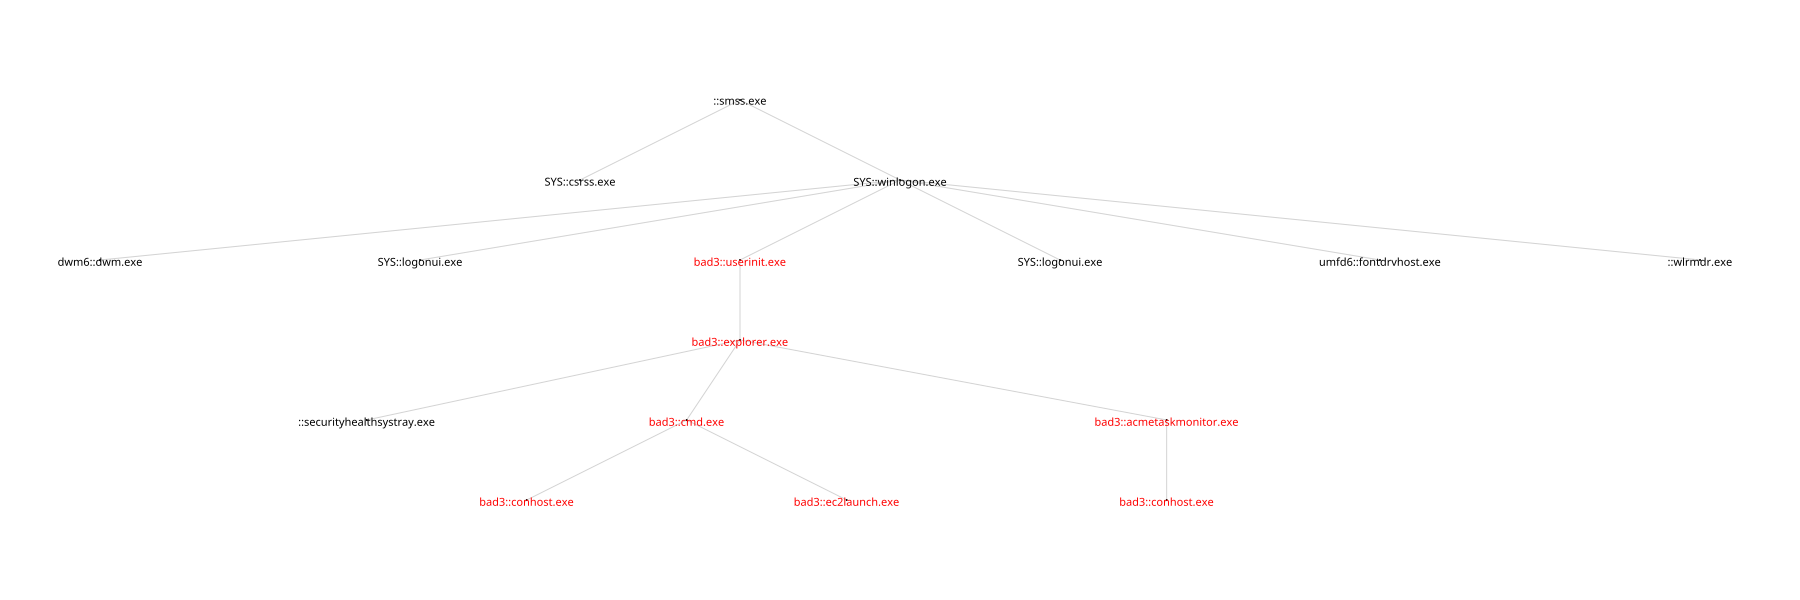

In [33]:
## pick one and visualize -- 16 nodes 6 layers ratio==0.25
tree = 18
root = 71
sg1 = pt.get_bfs_subtree(Trees, tree, root)
#ig.plot(sg1, 'tree_3.png', bbox=(1800,600), layout=sg1['ly'], margin=100, vertex_label_size=9, vertex_size=1, edge_color='lightgrey', edge_arrow_size=0)
ig.plot(sg1, bbox=(1800,600), layout=sg1['ly'], margin=100, vertex_label_size=11, vertex_size=1, edge_color='lightgrey', edge_arrow_size=0)


Below, we run our matching algorithm comparing the above tree with the other trees


In [34]:
## filter subtrees and apply Matching Algorithm 1
T = list(_df.tree)
R = list(_df.root)
L = list(_df.layers)
B = list(_df.badusers)

sum_bad = 0
sum_good = 0
Results = []
_sg1 = igio.igraph_to_treedata(sg1,phi_name='process')
min_score = 6
fast = fm.FastTreePathMatcher()

for i in range(len(T)):
    if T[i] != tree: 
        sg2 = pt.get_bfs_subtree(Trees, T[i], R[i])
        _sg2 = igio.igraph_to_treedata(sg2,phi_name='process')
        fast.fit(_sg1,_sg2)
        score = fast.predict()[1]
        if score >= min_score: ## required min common path length
            if B[i] == 0: ## look for subtrees without a baduser
                Results.append([T[i],R[i],L[i],sg2.vcount(),sg2.vs[0]['process'],int(score)])
                sum_bad += 1
            else:
                sum_good += 1
results_df = pd.DataFrame(Results, columns=['tree','root','layers','nodes','process','score'])
results_df.sort_values(by=['score','nodes'])


,tree,root,layers,nodes,process,score
10,66,180,6,12,smss.exe,6
1,16,7,6,14,smss.exe,6
2,16,11,6,14,smss.exe,6
11,211,16,10,14,smss.exe,6
8,55,173,7,15,smss.exe,6
4,25,132,6,16,smss.exe,6
9,57,40,6,16,smss.exe,6
7,43,68,10,20,smss.exe,6
3,22,101,7,24,smss.exe,6
5,27,14,7,24,smss.exe,6


#### visualize - highlight common path

* pick one of the hits from the table above
  

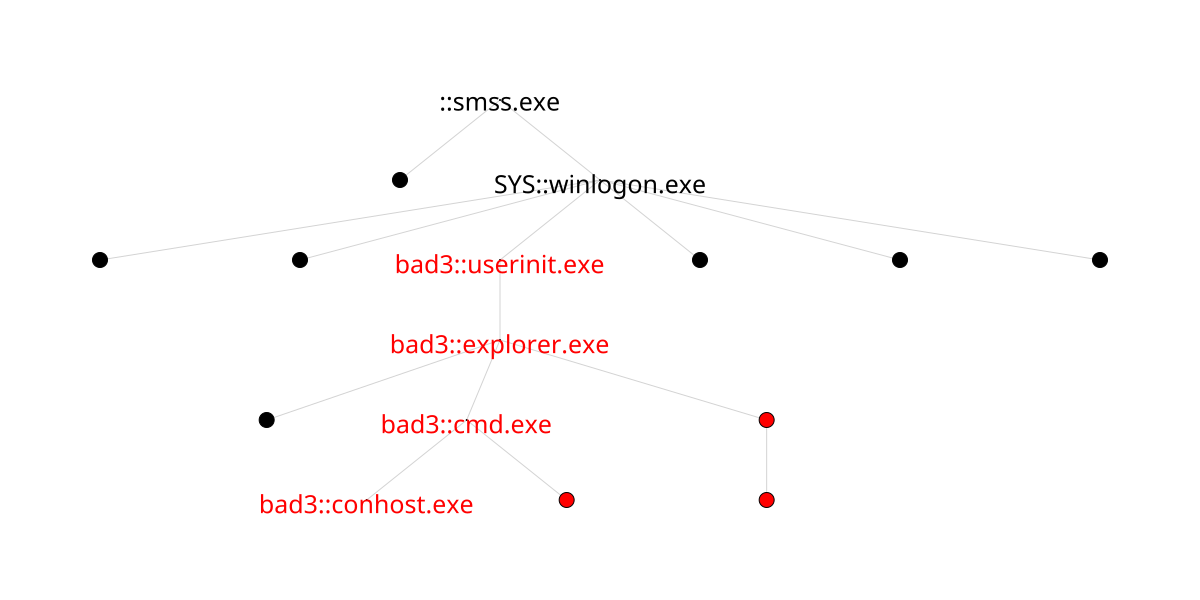

In [35]:
## pick one and visualize common path -- 
tree = 211
root = 16

sg2 = pt.get_bfs_subtree(Trees, tree, root)
_sg2 = igio.igraph_to_treedata(sg2,phi_name='process')
fast.fit(_sg1,_sg2)
paths, score = fast.predict()
#paths, score = gwm.basic_matcher(sg1, sg2, phi_name='process') ## node feature == process name

## plot reference tree (with baduser) - highlight the matched path
path = [int(x[0]) for x in paths]
sg1.vs['vertex_size'] = 15
sg1.vs['vertex_label_size'] = 1
for i in path:
    sg1.vs[i]['vertex_size'] = 1
    sg1.vs[i]['vertex_label_size'] = 25
ig.plot(sg1,
        bbox=(1200,600), layout=sg1['ly'], margin=100, 
        vertex_size=sg1.vs['vertex_size'], 
        vertex_label=sg1.vs['label'], 
        vertex_label_size=sg1.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


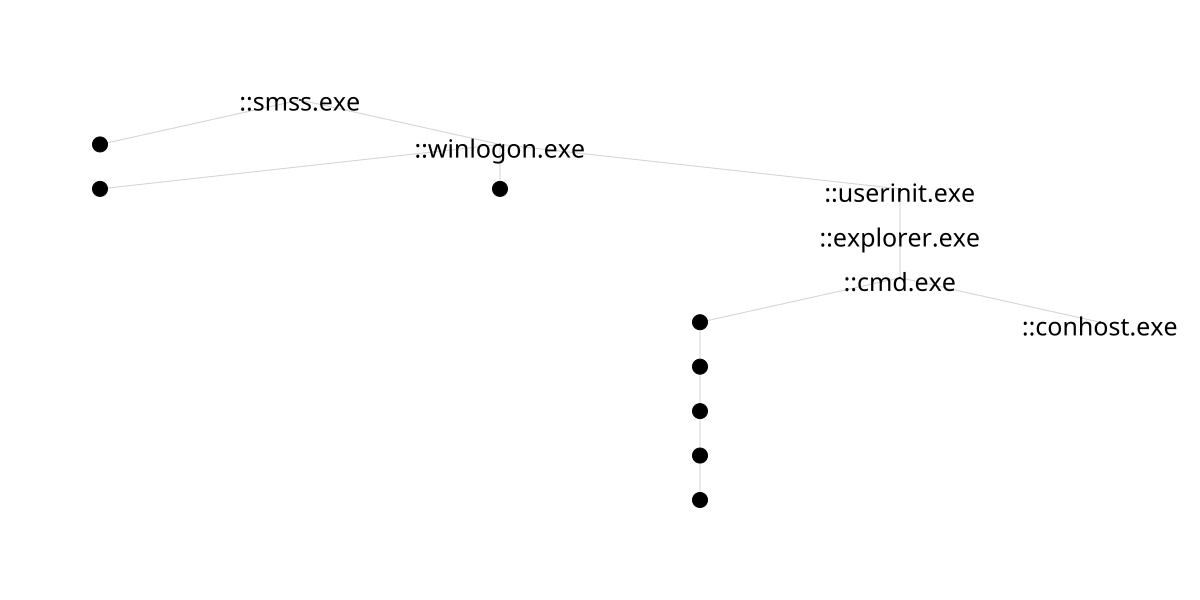

In [36]:
## plot top scoring tree - highlight the matched path
path = [int(x[1]) for x in paths]
sg2.vs['vertex_size'] = 15
sg2.vs['vertex_label_size'] = 1
for i in path:
    sg2.vs[i]['vertex_size'] = 1
    sg2.vs[i]['vertex_label_size'] = 25
ig.plot(sg2,
        bbox=(1200,600), layout=sg2['ly'], margin=100, 
        vertex_size=sg2.vs['vertex_size'], 
        vertex_label=sg2.vs['label'], 
        vertex_label_size=sg2.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


## Example 3 - using more detailed labels

* for the node labels, we use both the username and process name
* all ```userxx``` and ```badxx``` (```x``` are digits) are treated the same


In [37]:
%%time
import re

## pick the same base tree as in previous example
tree = 18
root = 71
sg1 = pt.get_bfs_subtree(Trees, tree, root) ## sub-tree above with required DFS labelling
sg1.vs['newlabel'] = [re.sub(r'user\d+::','user::',x) for x in sg1.vs['label']]
sg1.vs['newlabel'] = [re.sub(r'bad\d+::','user::',x) for x in sg1.vs['newlabel']]
_sg1 = igio.igraph_to_treedata(sg1, phi_name='newlabel')
min_score = 6
fast = fm.FastTreePathMatcher()

## filter subtrees and apply Matching Algorithm
_df = df_trees[ (df_trees.layers >= 4) & (df_trees.nodes < 40) ]
T = list(_df.tree)
R = list(_df.root)
L = list(_df.layers)
B = list(_df.badusers>0)
Results = []
for i in range(len(T)):
    if T[i] != tree:
        sg2 = pt.get_bfs_subtree(Trees, T[i], R[i])
        sg2.vs['newlabel'] = [re.sub(r'user\d+::','user::',x) for x in sg2.vs['label']]
        _sg2 = igio.igraph_to_treedata(sg2,phi_name='newlabel')
        fast.fit(_sg1,_sg2)
        score = fast.predict()[1]
        #_, score = gwm.basic_matcher(sg1, sg2, phi_name='newlabel') ## node feature == process name
        if score >= min_score: ## required min path length
            if B[i] == 0: ## look for subtrees without a baduser
                Results.append([T[i],R[i],L[i],sg2.vcount(),sg2.vs[0]['process'],int(score)])
results_df = pd.DataFrame(Results, columns=['tree','root','layers','nodes','process','score'])
results_df.sort_values(by='nodes')


CPU times: user 11 s, sys: 21.3 ms, total: 11 s
Wall time: 11 s


,tree,root,layers,nodes,process,score
0,25,132,6,16,smss.exe,6
2,57,40,6,16,smss.exe,6
1,43,68,10,20,smss.exe,6


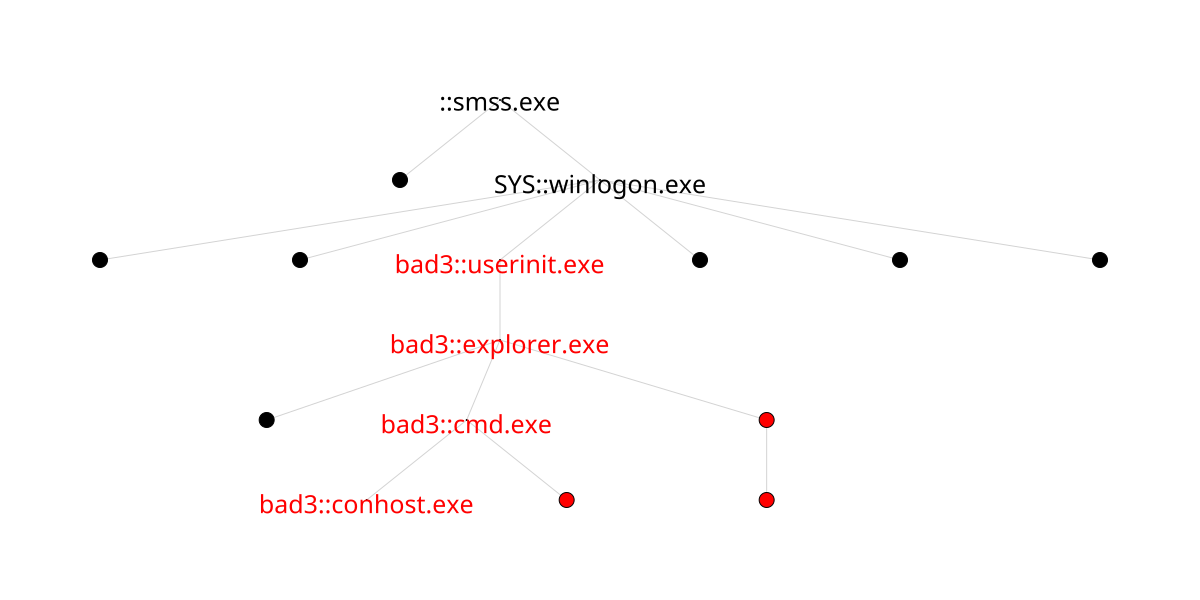

In [38]:
## pick one of the top hits and visualize common path -- 
tree = 43
root = 68
sg2 = pt.get_bfs_subtree(Trees, tree, root)
sg2.vs['newlabel'] = [re.sub(r'user\d+::','user::',x) for x in sg2.vs['label']]
_sg2 = igio.igraph_to_treedata(sg2,phi_name='newlabel')
fast.fit(_sg1,_sg2)
paths, score = fast.predict()
#paths, score = gwm.basic_matcher(sg1, sg2, phi_name='newlabel') ## node feature == process name

## plot reference tree
path = [int(x[0]) for x in paths]
sg1.vs['vertex_size'] = 15
sg1.vs['vertex_label_size'] = 1
for i in path:
    sg1.vs[i]['vertex_size'] = 1
    sg1.vs[i]['vertex_label_size'] = 25
ig.plot(sg1, bbox=(1200,600), layout=sg1['ly'], margin=100, 
        vertex_size=sg1.vs['vertex_size'], 
        vertex_label=sg1.vs['label'], 
        vertex_label_size=sg1.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)

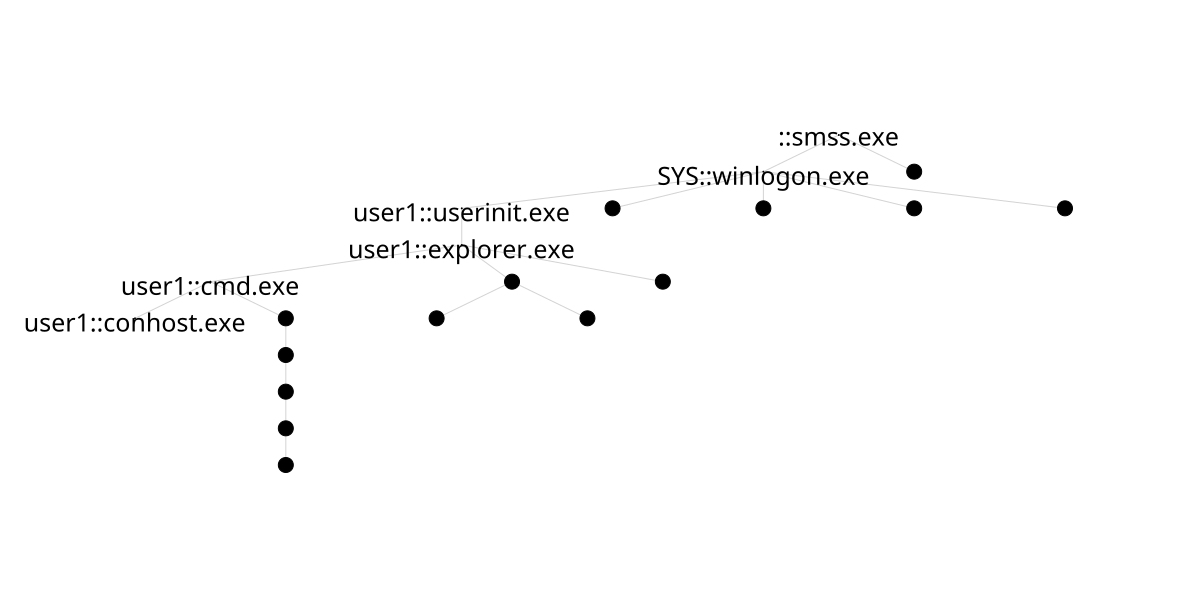

In [39]:
## plot top scoring tree
path = [int(x[1]) for x in paths]
sg2.vs['vertex_size'] = 15
sg2.vs['vertex_label_size'] = 1
for i in path:
    sg2.vs[i]['vertex_size'] = 1
    sg2.vs[i]['vertex_label_size'] = 25
ig.plot(sg2,
        bbox=(1200,600), layout=sg2['ly'], margin=135, 
        vertex_size=sg2.vs['vertex_size'], 
        vertex_label=sg2.vs['label'], 
        vertex_label_size=sg2.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)

## Example 4 - A different scoring function

* so far, we used a binary score for the node labels (match or not)
* we define a new score giving partial marks for matching process only, and full mark for matching process and user


In [40]:
def split_match(a,b):
    A = a.split('::')
    B = b.split('::')
    alpha = .75
    return (1-alpha)*int(A[0]==B[0]) + alpha*int(A[1]==B[1])


In [41]:
%%time
## pick same base tree
tree = 18
root = 71
sg1 = pt.get_bfs_subtree(Trees, tree, root) ## sub-tree above with required DFS labelling
sg1.vs['newlabel'] = [re.sub(r'user\d+::','user::',x) for x in sg1.vs['label']]
sg1.vs['newlabel'] = [re.sub(r'bad\d+::','user::',x) for x in sg1.vs['newlabel']]
min_score = 5.75

## filter subtrees and apply Matching Algorithm
_df = df_trees[ (df_trees.layers >= 4) & (df_trees.nodes < 80) ]
T = list(_df.tree)
R = list(_df.root)
L = list(_df.layers)
B = list(_df.badusers>0)
Results = []
for i in range(len(T)):
    if T[i] != tree:
        sg2 = pt.get_bfs_subtree(Trees, T[i], R[i])
        sg2.vs['newlabel'] = [re.sub(r'user\d+::','user::',x) for x in sg2.vs['label']]
        _, score = gwm.basic_matcher(sg1, sg2, phi_name='newlabel', w=split_match) ## slower algorithm
        if score >= min_score: ## required min path length
            if B[i] == 0: ## look for subtrees without a baduser
                Results.append([T[i],R[i],L[i],sg2.vcount(),sg2.vs[0]['process'],score])
results_df = pd.DataFrame(Results, columns=['tree','root','layers','nodes','process','score'])
results_df.sort_values(by='nodes')


CPU times: user 13.3 s, sys: 33.6 ms, total: 13.3 s
Wall time: 13.3 s


,tree,root,layers,nodes,process,score
6,55,173,7,15,smss.exe,5.75
2,25,132,6,16,smss.exe,6.00
7,57,40,6,16,smss.exe,6.00
5,43,68,10,20,smss.exe,6.00
1,22,101,7,24,smss.exe,5.75
0,12,928,7,31,smss.exe,5.75
8,60,35,6,45,smss.exe,5.75
9,208,60,6,57,smss.exe,6.00
4,38,46,6,62,smss.exe,6.00
3,32,18,9,77,smss.exe,6.00


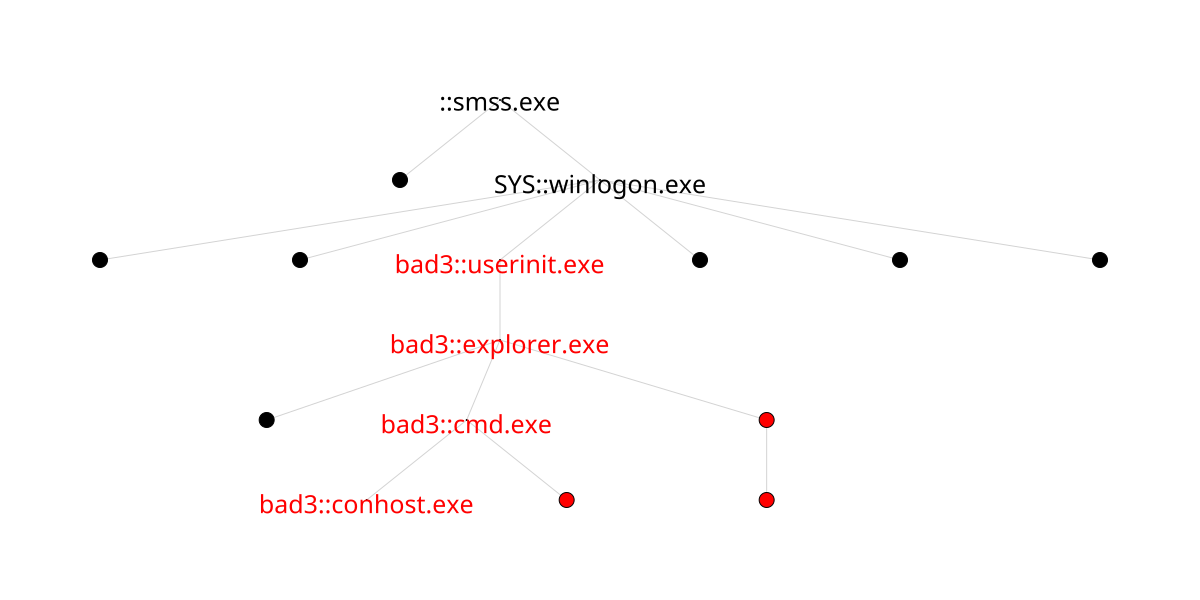

In [42]:
## pick one of the top hits and visualize common path 
tree = 55
root = 173
sg2 = pt.get_bfs_subtree(Trees, tree, root)
sg2.vs['newlabel'] = [re.sub(r'user\d+::','user::',x) for x in sg2.vs['label']]
paths, score = gwm.basic_matcher(sg1, sg2, phi_name='newlabel', w=split_match) ## node feature == process name

## plot reference tree
path = [int(x[0]) for x in paths]
sg1.vs['vertex_size'] = 15
sg1.vs['vertex_label_size'] = 1
for i in path:
    sg1.vs[i]['vertex_size'] = 1
    sg1.vs[i]['vertex_label_size'] = 25
ig.plot(sg1, bbox=(1200,600), layout=sg1['ly'], margin=100, 
        vertex_size=sg1.vs['vertex_size'], 
        vertex_label=sg1.vs['label'], 
        vertex_label_size=sg1.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)

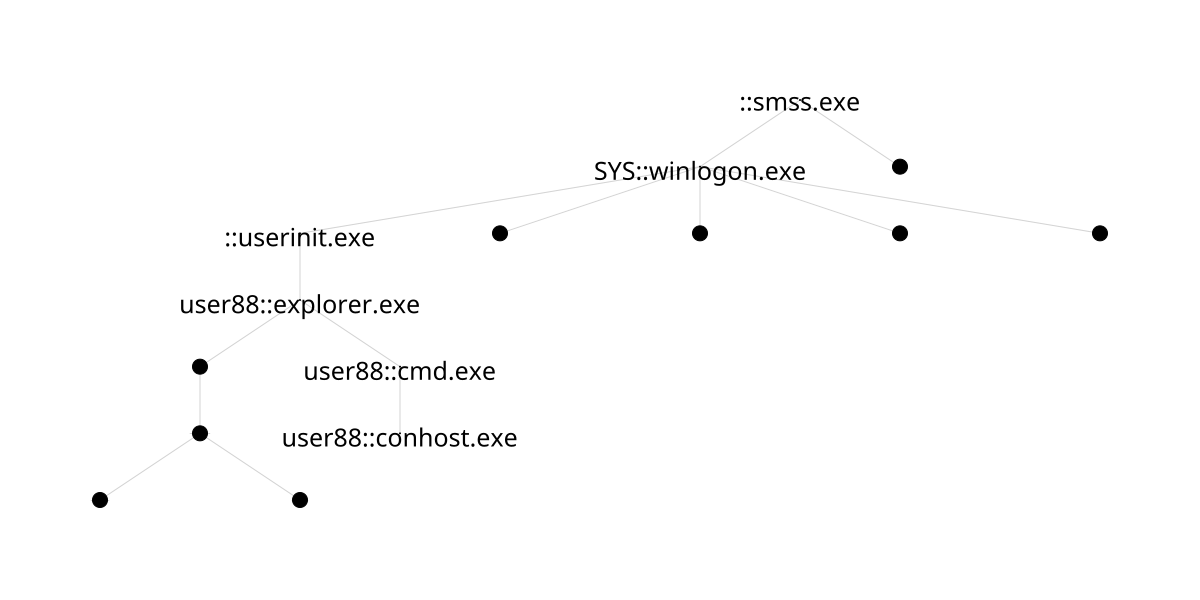

In [43]:
## plot top scoring tree
path = [int(x[1]) for x in paths]
sg2.vs['vertex_size'] = 15
sg2.vs['vertex_label_size'] = 1
for i in path:
    sg2.vs[i]['vertex_size'] = 1
    sg2.vs[i]['vertex_label_size'] = 25
ig.plot(sg2, 
        bbox=(1200,600), layout=sg2['ly'], margin=100, 
        vertex_size=sg2.vs['vertex_size'], 
        vertex_label=sg2.vs['label'], 
        vertex_label_size=sg2.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)

# Matching and Classification using multiple "templates"

* we use process tree with badusers as templates ($T_j$)
* we compute matching for all $T_j$ w.r.t. several other process trees $G_i$, where similarity matrix $X_{ij}$ stores the longest matches, where the node features are the process names.
   * **```Sim_match```**: similarity between templates and 473 small sub-trees (of size 100 or less) ; we use this to find closest matches to the whole set of templates
   * **```Sim_class```**: similarity between templates and 832 sub-trees (of size 500 or less) where the root process is one of {bash.exe, taskhostw.exe, cmd.exe, smss.exe} ; we use this for classification
* we use the $X_{ij}$ to rank/classify the $G_i$, for example via:
   * summing up all $X_{ij}$ for each $G_i$ 
   * counting the number of $X_{ij}>=k$ for each $G_i$ and some threshold $k$, i.e. number of path of length at least $k$ in common with the templates (```Sim_count```)


### extract some templates

In [44]:
## filter subtrees with badusers, minimum depth and maximum number of nodes
_df = df_trees[(df_trees.nodes<=100) & (df_trees.layers>=4) & (df_trees.badusers>0)]
print('Number of templates:',_df.shape[0])

## save template information
templates = []
for tree,root in zip(_df.tree,_df.root):
    sg1 = pt.get_bfs_subtree(Trees, tree, root) 
    if ('bad3' in set(sg1.vs['shortlabel'])) or ('bad9' in set(sg1.vs['shortlabel']) or ('bad88' in set(sg1.vs['shortlabel']))):
        templates.append((tree,root))


Number of templates: 38


## select trees without badusers and compute matching similarity with the templates

In [45]:
## filter subtrees without badusers, minimum depth and maximum number of nodes
_df = df_trees[(df_trees.nodes<=100) & (df_trees.layers>=4) & (df_trees.badusers==0)]
_df.shape


(475, 13)

In [46]:
%%time
Graphs = []
TreeData = []
T = list(_df.tree)
R = list(_df.root)
Sim_match = np.zeros(shape=(len(templates), len(T)))

## list all template graphs
for tree,root in templates:
    sg1 = pt.get_bfs_subtree(Trees, tree, root) ## sub-tree above with required DFS labelling
    Graphs.append(sg1)
    TreeData.append(igio.igraph_to_treedata(sg1, phi_name='process'))
## add trees to be compared 
for j in range(len(T)):
    sg2 = pt.get_bfs_subtree(Trees, T[j], R[j])
    Graphs.append(sg2)
    TreeData.append(igio.igraph_to_treedata(sg2, phi_name='process'))
    
## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(t) for t in TreeData]

## compare all high scoring with every template
Paths = []
l = len(templates)
for i in range(l):
    for j in range(len(T)):
        _, score = fast.predict_encoded(enc[i], enc[j+l])
        Sim_match[i,j] = score

CPU times: user 14.9 s, sys: 24.6 ms, total: 14.9 s
Wall time: 14.9 s


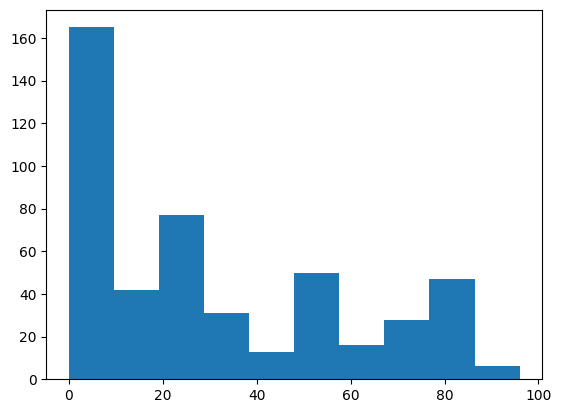

In [47]:
## summing up all S_ij
plt.hist(Sim_match.sum(axis=0));

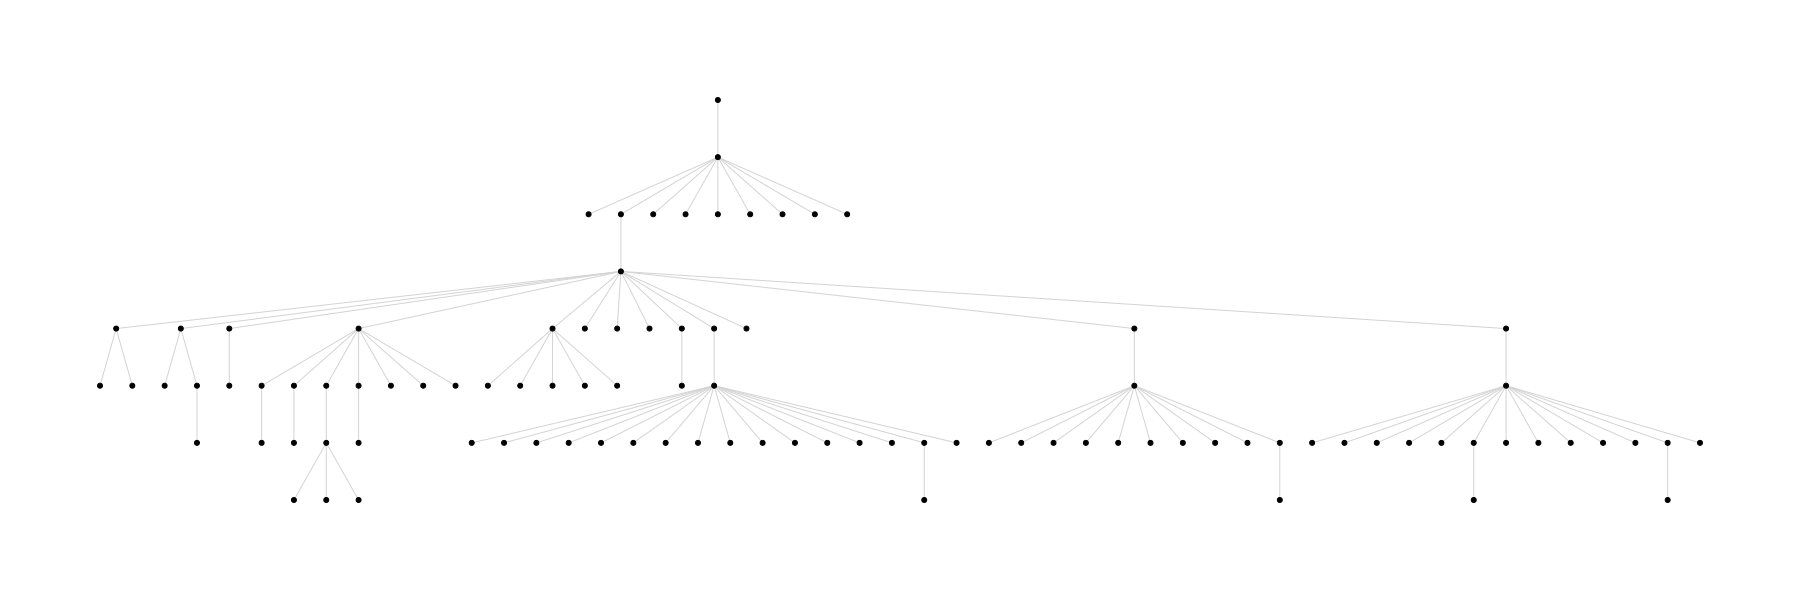

In [48]:
## plot tree with largest sum
T = list(_df.tree)
R = list(_df.root)
m = np.argmax(Sim_match.sum(axis=0))
sg2 = pt.get_bfs_subtree(Trees, T[m], R[m])
ig.plot(sg2, bbox=(1800,600), layout=sg2['ly'], margin=100, vertex_label_size=0, vertex_size=5, edge_color='lightgrey', edge_arrow_size=0)


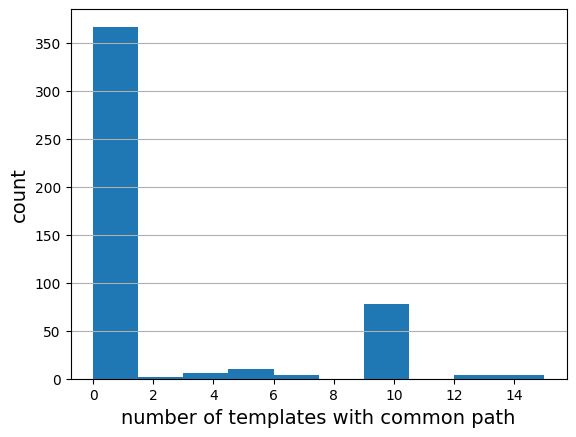

In [49]:
## now count number of S_ij >= 3, i.e. number of "long" paths in common
plt.hist((Sim_match>=3).sum(axis=0))
plt.xlabel('number of templates with common path', fontsize=14)
plt.ylabel('count', fontsize=14)
plt.grid(axis='y');
#plt.savefig('acme_classify.png');


In [50]:
Counter((Sim_match>=3).sum(axis=0))


Counter({np.int64(0): 362,
         np.int64(9): 70,
         np.int64(5): 10,
         np.int64(10): 8,
         np.int64(1): 5,
         np.int64(6): 4,
         np.int64(4): 4,
         np.int64(12): 4,
         np.int64(15): 4,
         np.int64(2): 2,
         np.int64(3): 2})

### EDA on the above results with matching scores

* show that matching trees are generally bigger
* extract common path(s) in high scoring trees
  

median values: 22.0 6.0


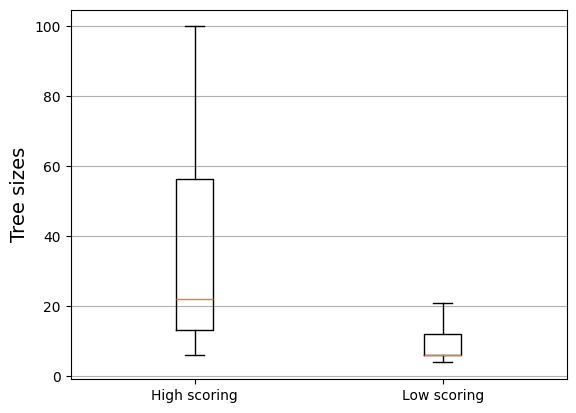

In [51]:
Scores = np.array((Sim_match>=3).sum(axis=0))
## high scores
H = []
for i in np.where(Scores >= 9)[0]:
    t = T[i]
    r = R[i]
    sg2 = pt.get_bfs_subtree(Trees, t, r)
    H.append(sg2.vcount())
## low scores
L = []
for i in np.where(Scores < 9)[0]:
    t = T[i]
    r = R[i]
    sg2 = pt.get_bfs_subtree(Trees, t, r)
    L.append(sg2.vcount())
plt.boxplot([H,L], showfliers=False, tick_labels=['High scoring','Low scoring'])
plt.ylabel('Tree sizes', fontsize=14)
plt.grid(axis='y');
print('median values:',np.median(H),np.median(L))


### frequent matching sequences

In [52]:
%%time
Graphs = []
TreeData = []

## list all template graphs
for tree,root in templates:
    sg1 = pt.get_bfs_subtree(Trees, tree, root) ## sub-tree above with required DFS labelling
    Graphs.append(sg1)
    TreeData.append(igio.igraph_to_treedata(sg1, phi_name='process'))
## add high scoring trees 
for j in range(len(T)):
    sg2 = pt.get_bfs_subtree(Trees, T[j], R[j])
    Graphs.append(sg2)
    TreeData.append(igio.igraph_to_treedata(sg2, phi_name='process'))
    
## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(T) for T in TreeData]

## compare all high scoring with every template
Paths = []
for i in range(len(templates)):
    for j in np.arange(len(templates), len(TreeData)):
        _, score = fast.predict_encoded(enc[i], enc[j])
        if int(score) >= 3:
            Paths.append([Graphs[i].vs[x[0]]['process'] for x in _[:int(score)]])
_Paths = ['::'.join((x)) for x in Paths]
Counter(_Paths)


CPU times: user 15.1 s, sys: 40.7 ms, total: 15.2 s
Wall time: 15.2 s


Counter({'userinit.exe::explorer.exe::cmd.exe::conhost.exe': 307,
         'explorer.exe::cmd.exe::conhost.exe': 255,
         'winlogon.exe::userinit.exe::explorer.exe::cmd.exe::conhost.exe': 164,
         'firefox.exe::firefox.exe::pingsender.exe::conhost.exe': 42,
         'cmd.exe::cmd.exe::conhost.exe': 36,
         'smss.exe::winlogon.exe::userinit.exe::explorer.exe::cmd.exe::conhost.exe': 22,
         'winlogon.exe::userinit.exe::explorer.exe': 21,
         'vs_setup_bootstrapper.exe::setup.exe::vs_installer.windows.exe::conhost.exe': 8,
         'setup.exe::vs_installer.windows.exe::conhost.exe': 6,
         'explorer.exe::setup.exe::setup.exe': 5,
         'firefox.exe::firefox.exe::firefox.exe': 5,
         'explorer.exe::devenv.exe::microsoft.servicehub.controller.exe::servicehub.identityhost.exe': 5,
         'explorer.exe::firefox.exe::firefox.exe::pingsender.exe::conhost.exe': 5,
         'explorer.exe::powershell.exe::conhost.exe': 5,
         'setup.exe::setup.exe::conh

So most common path by far is:

```winlogon.exe::userinit.exe::explorer.exe::cmd.exe::conhost.exe```

and its 4 and 3-long tails.


## Classification of rooted trees

* we use the same templates as above
* we focus of 4 frequent root processes
  

In [53]:
## filter subtrees without badusers, minimum depth and maximum number of nodes
_df = df_trees[(df_trees.nodes<=500) & (df_trees.layers>=3) & (df_trees.badusers==0)]
Counter(_df.process).most_common(5)


[('bash.exe', 490),
 ('taskhostw.exe', 148),
 ('cmd.exe', 116),
 ('smss.exe', 81),
 ('setup.exe', 38)]

In [54]:
_df = _df[ (_df.process == 'cmd.exe') | (_df.process ==  'bash.exe') | (_df.process ==  'taskhostw.exe') | (_df.process ==  'smss.exe')]
_df.shape


(835, 13)

In [55]:
%%time
Graphs = []
TreeData = []
T = list(_df.tree)
R = list(_df.root)
Sim_class = np.zeros(shape=(len(templates), len(T)))

## list all template graphs
for tree,root in templates:
    sg1 = pt.get_bfs_subtree(Trees, tree, root) ## sub-tree above with required DFS labelling
    Graphs.append(sg1)
    TreeData.append(igio.igraph_to_treedata(sg1, phi_name='process'))
## add trees to be compared 
for j in range(len(T)):
    sg2 = pt.get_bfs_subtree(Trees, T[j], R[j])
    Graphs.append(sg2)
    TreeData.append(igio.igraph_to_treedata(sg2, phi_name='process'))
    
## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(t) for t in TreeData]

## compare all high scoring with every template
Paths = []
l = len(templates)
for i in range(l):
    for j in range(len(T)):
        _, score = fast.predict_encoded(enc[i], enc[j+l])
        Sim_class[i,j] = score

CPU times: user 29.3 s, sys: 47.2 ms, total: 29.3 s
Wall time: 29.3 s


In [56]:
label_map = {v:k for k,v in enumerate(['bash.exe','smss.exe','taskhostw.exe','cmd.exe'])}
X = Sim_class.T.tolist()
y = [label_map[i] for i in _df.process]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=44, stratify=y)
rf = RandomForestClassifier(n_jobs=16, random_state=44)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


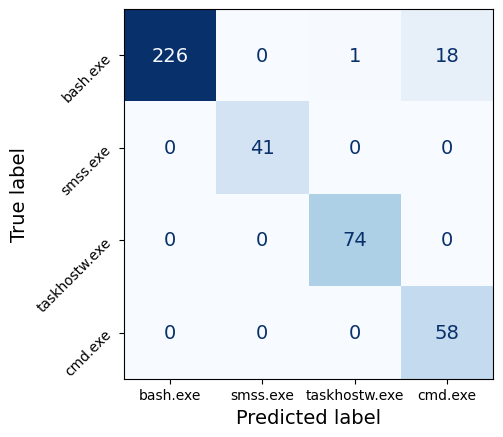

Closing duckdb

In [57]:
## confusion matrix
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
plt.rcParams.update({'font.size': 14}) # Change to your desired size
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=list(label_map.keys())
                             )
disp.plot(colorbar=False, cmap='Blues')
plt.xticks(fontsize=10)
plt.yticks(rotation=45, fontsize=10)
#plt.savefig('acme_confusion.png')
plt.show()
